<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 210%;text-align: center;border-radius: 10px 70px">
    Airline Passenger Forecasting 
</center></p></h1>

<a class="anchor" id="setup"></a>
<br>
<br>
<br>
<font style="font-family:Gabriola; font-size:300%;">1️⃣ Step 1 | About Dataset </font><br>
 <br>   
<br>

<div style="border-radius: 5px; font-family: cursive; border: 3px solid #008000; text-align: justify; color: black; font-size: 14px; padding: 10px; background:#F2FFFF;">

  <p style="text-align: justify; font-family: cursive; font-size: 14px; color: green; font-weight: bold;">
        About the Dataset: Airline Passenger Time Series
  </p>

  <p style="text-align: justify; font-family: cursive; font-size: 14px; color: black;">
        The <strong>Airline Passenger Dataset</strong> is one of the most iconic and widely used benchmark datasets in the field of
        <strong>time series analysis and forecasting</strong>. It contains monthly totals of international airline passengers, making it ideal for identifying
        <strong>trends</strong>, <strong>seasonal effects</strong>, and <strong>long-term patterns</strong>.
  </p>

  <p style="text-align: justify; font-family: cursive; font-size: 14px; color: green; font-weight: bold;">
        Dataset Details
  </p>

  <ul style="font-family: cursive; font-size: 14px; color: black;">
        <li><strong>Type:</strong> Univariate Time Series</li>
        <li><strong>Frequency:</strong> Monthly observations</li>
        <li><strong>Variable:</strong> Number of international airline passengers</li>
        <li><strong>Format:</strong> Continuous monthly data</li>
  </ul>

  <p style="text-align: justify; font-family: cursive; font-size: 14px; color: green; font-weight: bold;">
        Columns
  </p>

  <ul style="font-family: cursive; font-size: 14px; color: black;">
        <li><strong>Month:</strong> Date information in monthly format</li>
        <li><strong>Passengers:</strong> Number of passengers (in thousands)</li>
  </ul>

  <p style="text-align: justify; font-family: cursive; font-size: 14px; color: black;">
        This dataset is widely used by <strong>students</strong>, <strong>data scientists</strong>, and <strong>researchers</strong> to compare and practice various forecasting techniques — including classical statistical models such as <strong>ARIMA</strong> and <strong>SARIMA</strong>, as well as advanced deep learning models like <strong>Prophet</strong>, <strong>LSTM</strong>, <strong>GRU</strong>.
        It remains a staple dataset for understanding time-dependent patterns and seasonality.
  </p>

</div>


https://www.kaggle.com/datasets/vedatgul/airline-passengers

<a class="anchor" id="setup"></a>
<br>
<br>
<br>
<font style="font-family:Gabriola; font-size:300%;">3️⃣ Step 2 | Python Libraries </font><br>
 <br>   
<br>

In [ ]:
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns


from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
import itertools
from prophet import Prophet



from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score,mean_absolute_percentage_error
from math import sqrt

import warnings 
warnings.filterwarnings('ignore')

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Data Loading  
</center></p></h1>

In [3]:
df_1 = pd.read_csv(r'D:\Data Analysis- Scientist\Mchine Learning\Projects\Dataset for energy\Time series - Sale and Energy\Airline-passenger-forecasting\airline-passengers.csv')
df = df_1.copy() # fro heatmap and feature analysis

In [4]:
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Basic Understanding Data  
</center></p></h1>

In [5]:
# info from of datasets
print(' shape of data set is = ',df.shape)
print()

print(' dataset head:\n')
df.head()
print()

print(' dataset info:\n')
dfinfo=df.info()
print()

print(' describtion of data set:\n')
df_des=df.describe().transpose()
df_des


 shape of data set is =  (144, 2)

 dataset head:


 dataset info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       144 non-null    object
 1   Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB

 describtion of data set:



,count,mean,std,min,25%,50%,75%,max
Passengers,144.0,280.298611,119.966317,104.0,180.0,265.5,360.5,622.0


## Handle missing values

In [6]:
# Check for missing values
df.isnull().sum()

Month         0
Passengers    0
dtype: int64

In [16]:
df['Passengers'] = df['Passengers'].fillna(df['Passengers'].rolling(3, min_periods=1).mean())

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Distribution and anlaysis data
</center></p></h1>

# Distribution and analysing dataset

<Figure size 1280x960 with 0 Axes>

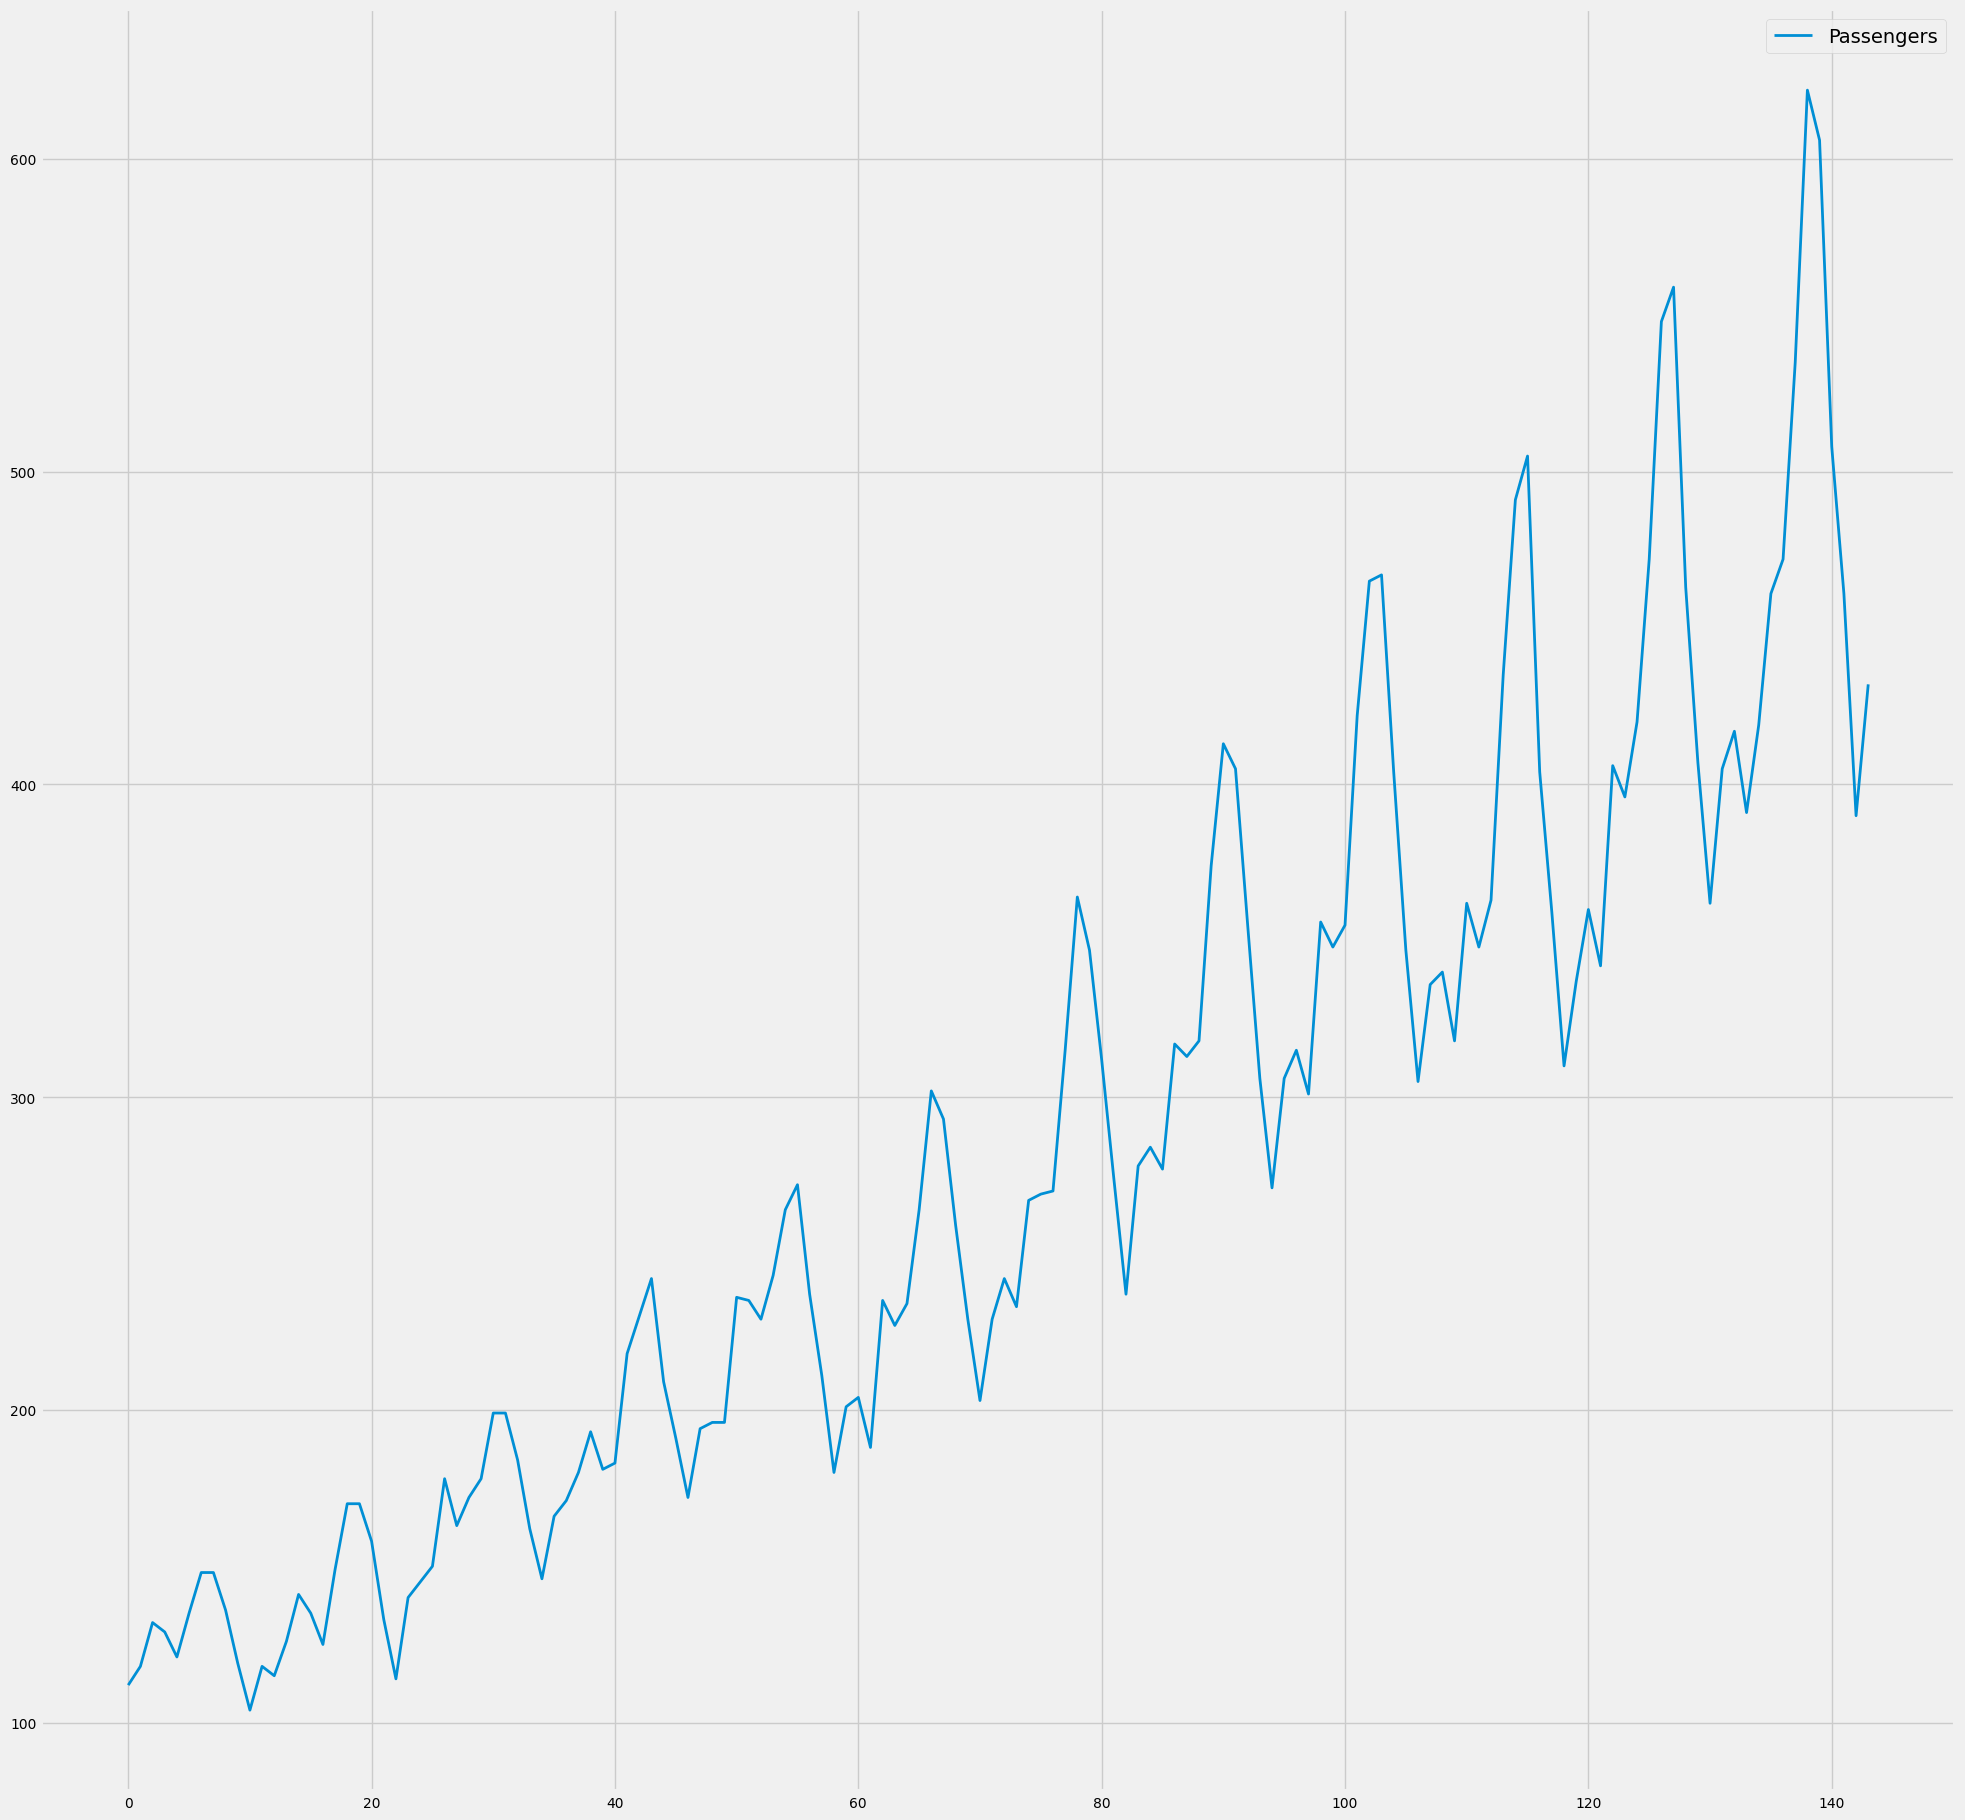

In [8]:
# Visualization of the primary dataset
plt.figure(dpi=200)
plt.style.use('fivethirtyeight')
df.plot(subplots=True, figsize=(22, 22), fontsize=10, linewidth=2, sharex=False)
plt.show()

In [ ]:


fig = sp.make_subplots(rows=len(df.columns), cols=1, shared_xaxes=True)

for i, column in enumerate(df.columns, 1):
    fig.add_trace(
        go.Scatter(x=df.index, y=df[column], mode='lines', name=column),
        row=i, col=1
    )

fig.update_layout(
    title="Interactive Multi-Feature Time Series",
    height=300 * len(df.columns),
    template="plotly_white",
)

fig.show()


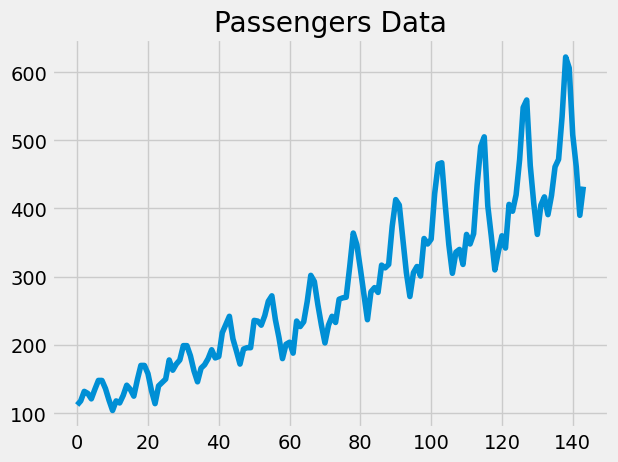

In [11]:
df['Passengers'].plot(title='Passengers Data')
plt.show()

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Check for stationarity by Adfuller
</center></p></h1>



## 🎯 Key Insights
- Time series needs to be **stationary** before ARIMA modeling.  
- **AIC optimization** helps in selecting the best model parameters.  
- ARIMA provides solid results for datasets with **trend and seasonality**. 



In [17]:
# Function to perform Augmented Dickey-Fuller test
series = df['Passengers']

adf_result = adfuller(series)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Number of Lags Used:", adf_result[2])
print("Number of Observations:", adf_result[3])
print("Critical Values:")

for key, value in adf_result[4].items():
    print(f"   {key}: {value}")

ADF Statistic: 0.8153688792060463
p-value: 0.991880243437641
Number of Lags Used: 13
Number of Observations: 130
Critical Values:
   1%: -3.4816817173418295
   5%: -2.8840418343195267
   10%: -2.578770059171598


<div style="border-radius: 5px; font-family: cursive; border: 3px solid #008000; text-align: justify; color: black; font-size: 14px; padding: 10px; background:#F2FFFF;">
 <p style="text-align: justify; font-family: cursive; font-size: 14px; color: green; font-weight: bold;">
        Augmented Dickey-Fuller (ADF) Test Results
    </p>

  <p style="text-align: justify; font-family: cursive; font-size: 14px; color: black;">
        The ADF test was performed to evaluate whether the time series is <strong>stationary</strong> or 
        <strong>non-stationary</strong>.
        Below is the summary of the obtained test statistics:
    </p>

 <ul style="font-family: cursive; font-size: 14px; color: black;">
        <li><strong>ADF Statistic:</strong> 0.815</li>
        <li><strong>p-value:</strong> 0.991</li>
        <li><strong>Critical Values:</strong> -3.48 (1%), -2.88 (5%), -2.57 (10%)</li>
    </ul>

  <p style="text-align: justify; font-family: cursive; font-size: 14px; color: black;">
        Since the <strong>p-value is extremely high (0.991)</strong>—far greater than 0.05—we 
        <strong>cannot reject the null hypothesis</strong>, which states that the time series 
        contains a <strong>unit root</strong> and is therefore <strong>non-stationary</strong>.
    </p>

 <p style="text-align: justify; font-family: cursive; font-size: 14px; color: black;">
        Additionally, the <strong>ADF statistic (0.815)</strong> is much higher than all critical values, 
        which further confirms that the series is <strong>not stationary</strong>. 
        A stationary series should have an ADF value <strong>lower</strong> (more negative) than the critical thresholds.
    </p>

 <p style="text-align: justify; font-family: cursive; font-size: 14px; color: green; font-weight: bold;">
        Required Next Steps Before Modeling
    </p>

 <p style="text-align: justify; font-family: cursive; font-size: 14px; color: black;">
        Because the time series is non-stationary, it must be transformed before ARIMA or any forecasting model is applied.
        The following techniques can be used to make the series stationary:
    </p>

  <ul style="font-family: cursive; font-size: 14px; color: black;">
        <li>✔ Apply <strong>differencing</strong> (first difference or seasonal difference)</li>
        <li>✔ Apply a <strong>log transformation</strong> to stabilize variance</li>
        <li>✔ Remove trend and seasonality if present</li>
        <li>✔ Re-run the ADF test after each transformation to confirm stationarity</li>
    </ul>

  <p style="text-align: justify; font-family: cursive; font-size: 14px; color: green; font-weight: bold;">
        Proceeding Toward ARIMA Modeling
    </p>

  <p style="text-align: justify; font-family: cursive; font-size: 14px; color: black;">
        After achieving stationarity, we can proceed with ARIMA modeling. 
        ARIMA involves three parameters: <strong>p, d, q</strong>.
        In this case, since the series is currently not stationary, the <strong>d</strong> value will be at least 1 
        (or more depending on the transformation needed).
    </p>

</div>


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
     Method for stationarity
</center></p></h1>

## Differencing 

In [21]:

data_diff = df['Passengers'].diff().dropna()
data_diff

1       6.0
2      14.0
3      -3.0
4      -8.0
5      14.0
       ... 
139   -16.0
140   -98.0
141   -47.0
142   -71.0
143    42.0
Name: Passengers, Length: 143, dtype: float64

## Log Transformation 

In [22]:
data_log = np.log(df['Passengers'])
data_log

0      4.718499
1      4.770685
2      4.882802
3      4.859812
4      4.795791
         ...   
139    6.406880
140    6.230481
141    6.133398
142    5.966147
143    6.068426
Name: Passengers, Length: 144, dtype: float64

In [24]:
train_size = int(len(df) * 0.8)
train = df[:train_size]
test = df[train_size:]

In [30]:
print(f"shape of x train: {train.shape}")
print(f"shape of x test: {test.shape}")


shape of x train: (115, 2)
shape of x test: (29, 2)


In [27]:
train


,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
110,1958-03,362
111,1958-04,348
112,1958-05,363
113,1958-06,435


In [31]:
print(train.dtypes)

Month         object
Passengers     int64
dtype: object


<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> Models</p>
</div>

# ================================
# SimpleExpSmoothing

# ================================

In [32]:
df['Month'] = pd.to_datetime(df['Month'], format='%Y-%m')
df.set_index('Month', inplace=True)

In [35]:
df

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [ ]:
# ------------ 1) Fit SES Model ----------------
alpha = 0.2
model = SimpleExpSmoothing(train['Passengers']).fit(smoothing_level=alpha)

# ------------ 2) Forecast ---------------------
y_pred = model.forecast(len(test))

# ------------ 3) Evaluation -------------------
#  test['Passengers']
mae = mean_absolute_error(test['Passengers'], y_pred)
rmse = np.sqrt(mean_squared_error(test['Passengers'], y_pred))

print("MAE =", mae)
print("RMSE =", rmse)

MAE = 66.93188618480598
RMSE = 90.6692270894933


In [38]:
# Align forecast index with test
y_pred = pd.Series(y_pred.values, index=test.index)
y_pred

115    394.305792
116    394.305792
117    394.305792
118    394.305792
119    394.305792
120    394.305792
121    394.305792
122    394.305792
123    394.305792
124    394.305792
125    394.305792
126    394.305792
127    394.305792
128    394.305792
129    394.305792
130    394.305792
131    394.305792
132    394.305792
133    394.305792
134    394.305792
135    394.305792
136    394.305792
137    394.305792
138    394.305792
139    394.305792
140    394.305792
141    394.305792
142    394.305792
143    394.305792
dtype: float64

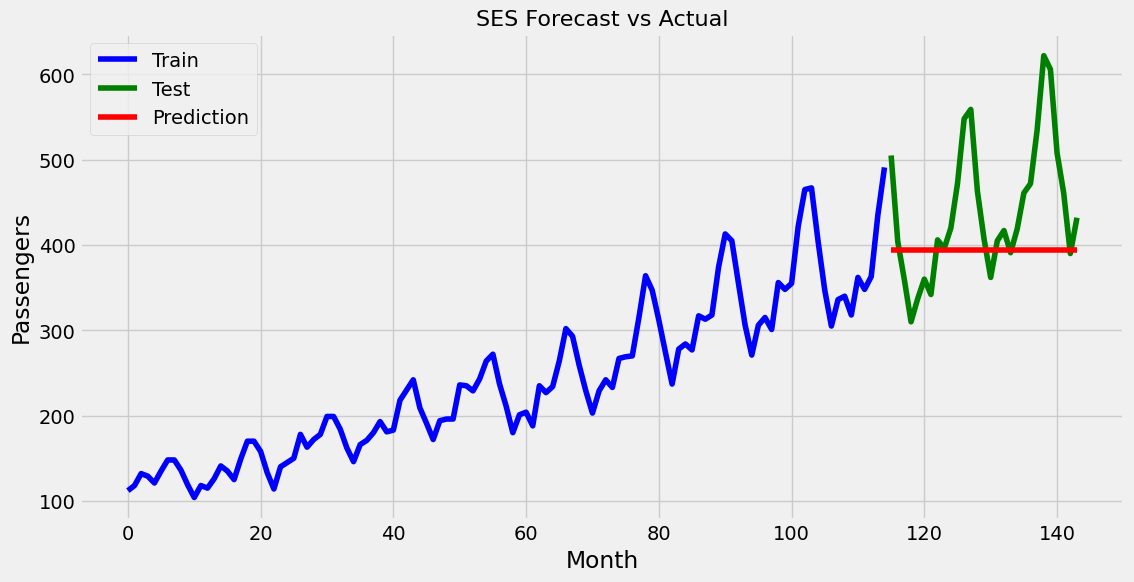

In [ ]:

plt.figure(figsize=(12,6))

# 
plt.plot(train.index, train['Passengers'], label='Train', color='blue')
plt.plot(test.index, test['Passengers'], label='Test', color='green')
plt.plot(test.index, y_pred, label='Prediction', color='red')

plt.title("SES Forecast vs Actual", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.legend()
plt.grid(True)
plt.show()


# ================================
# ARIMA

# ================================


In [42]:

# ------------ 1) Fit ARIMA Model ----------------
model = ARIMA(train['Passengers'], order=(2,0,2))
model_fit = model.fit()

# ------------ 2) Forecast -----------------------
# طول forecast = طول test
predictions = model_fit.predict(start=len(train), end=len(train)+len(test)-1)

# ------------ 3) Evaluation ---------------------
rmse = sqrt(mean_squared_error(test['Passengers'], predictions))
print("RMSE =", rmse)

RMSE = 114.88781955043426


In [43]:

# ------------ 1) Fit ARIMA Model ----------------
model = ARIMA(train['Passengers'], order=(2,1,2))
model_fit = model.fit()

# ------------ 2) Forecast -----------------------
# طول forecast = طول test
predictions = model_fit.predict(start=len(train), end=len(train)+len(test)-1)

# ------------ 3) Evaluation ---------------------
rmse = sqrt(mean_squared_error(test['Passengers'], predictions))
print("RMSE =", rmse)

RMSE = 82.51301140607121


In [44]:
# ------------ 1) Fit ARIMA Model ----------------
model = ARIMA(train['Passengers'], order=(2,2,2))
model_fit = model.fit()

# ------------ 2) Forecast -----------------------
# طول forecast = طول test
predictions = model_fit.predict(start=len(train), end=len(train)+len(test)-1)

# ------------ 3) Evaluation ---------------------
rmse = sqrt(mean_squared_error(test['Passengers'], predictions))
print("RMSE =", rmse)

RMSE = 135.58293797877542


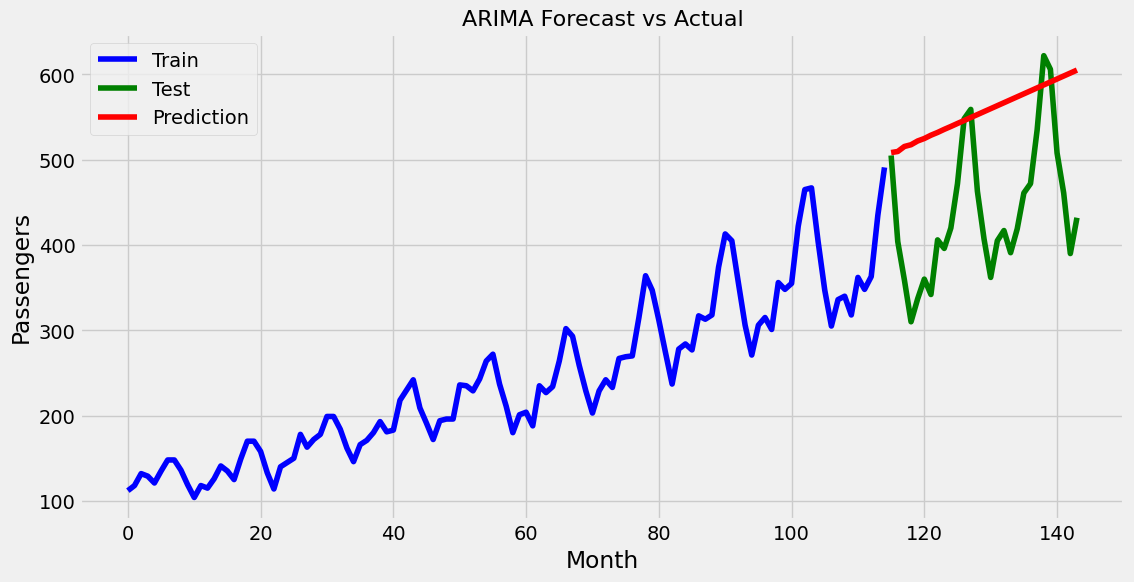

In [47]:


# 4) Plot
plt.figure(figsize=(12,6))
plt.plot(train.index, train['Passengers'], label='Train', color='blue')
plt.plot(test.index, test['Passengers'], label='Test', color='green')
plt.plot(test.index, predictions, label='Prediction', color='red')  # ✅ استفاده از predictions
plt.title("ARIMA Forecast vs Actual", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.legend()
plt.grid(True)
plt.show()

<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> ACF & PACF Plots</p>
</div>

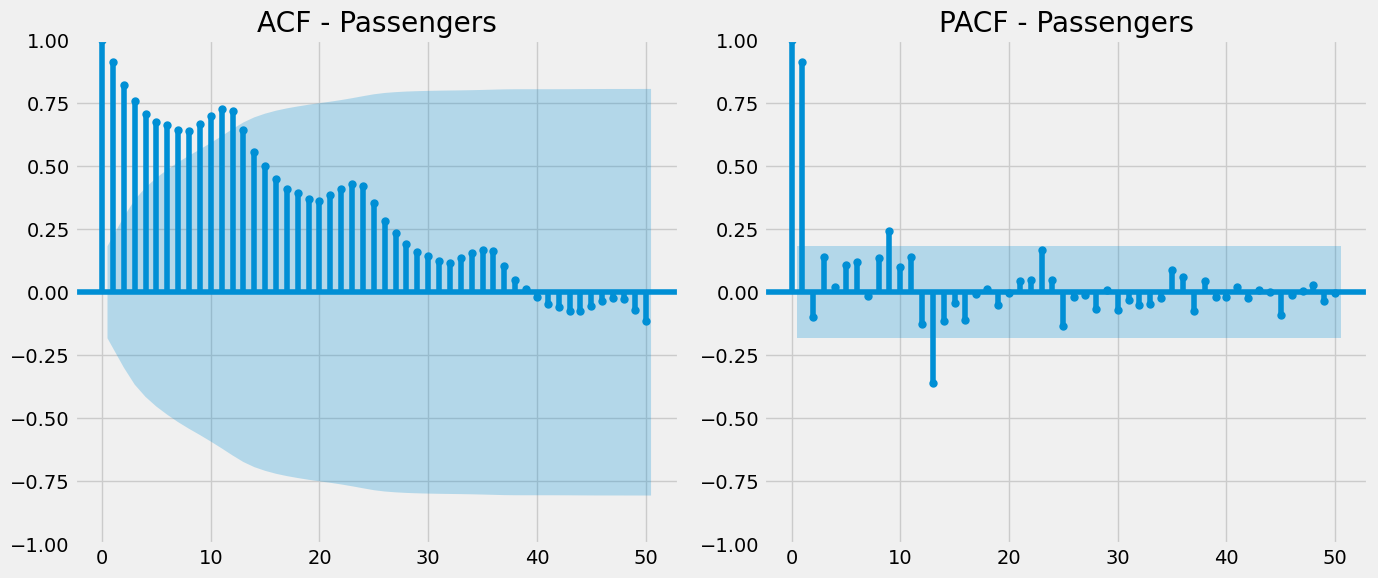

In [49]:

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plot_acf(train['Passengers'], lags=50, ax=plt.gca())
plt.title("ACF - Passengers")

plt.subplot(1,2,2)
plot_pacf(train['Passengers'], lags=50, ax=plt.gca())
plt.title("PACF - Passengers")

plt.tight_layout()
plt.show()

<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> auto_arima  #pmdarima</p>
</div>

In [51]:
auto_model = auto_arima(train['Passengers'],
                        start_p=0, start_q=0,
                        max_p=5, max_q=5,
                        seasonal=True, m=12,
                        stepwise=True,
                        trace=True)

print(auto_model.summary())

auto_pred = auto_model.predict(n_periods=len(test))
auto_pred = pd.Series(auto_pred, index=test.index)

# Evaluation Auto ARIMA
rmse_auto = sqrt(mean_squared_error(test['Passengers'], auto_pred))
mae_auto = mean_absolute_error(test['Passengers'], auto_pred)
print("Auto ARIMA - MAE:", mae_auto, "RMSE:", rmse_auto)


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=758.922, Time=0.17 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=757.826, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=755.750, Time=0.13 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=756.380, Time=0.09 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=755.499, Time=0.03 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=755.982, Time=0.08 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=757.649, Time=0.17 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=756.771, Time=0.04 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=756.022, Time=0.14 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=756.011, Time=0.05 sec
 ARIMA(2,1,1)(0,1,0)[12]             : AIC=757.976, Time=0.13 sec
 ARIMA(1,1,0)(0,1,0)[12] intercept   : AIC=757.438, Time=0.04 sec

Best model:  ARIMA(1,1,0)(0,1,0)[12]          
Total fit time: 1.133 seconds
                                     SARIMAX Results                                   

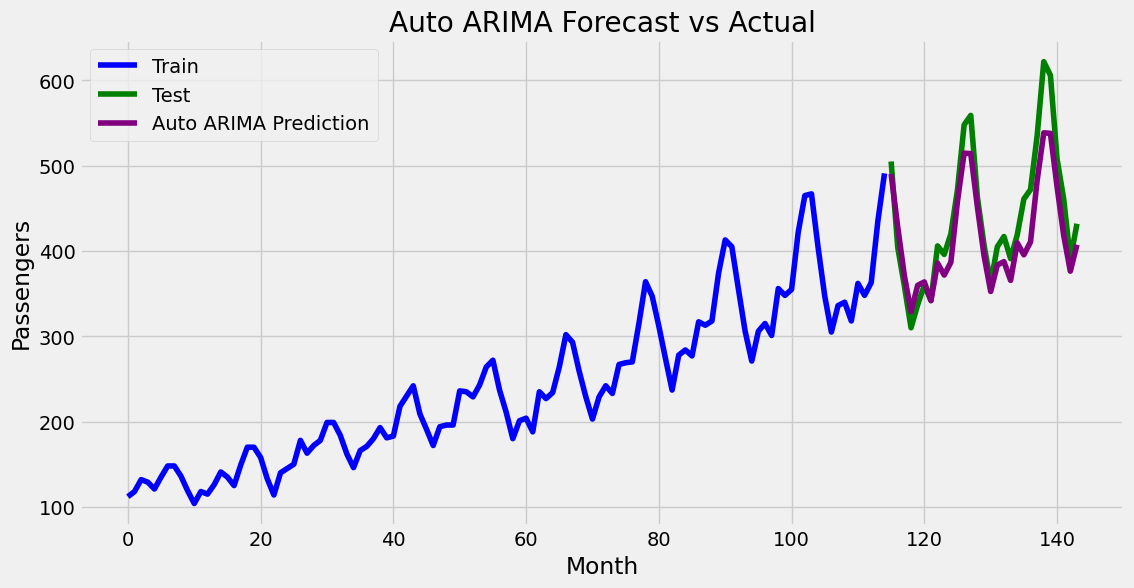

In [52]:

# Plot Auto ARIMA
plt.figure(figsize=(12,6))
plt.plot(train.index, train['Passengers'], label='Train', color='blue')
plt.plot(test.index, test['Passengers'], label='Test', color='green')
plt.plot(test.index, auto_pred, label='Auto ARIMA Prediction', color='purple')
plt.title("Auto ARIMA Forecast vs Actual")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.legend()
plt.grid(True)
plt.show()

<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> Forecast 30 days ahead </p>
</div>

In [53]:
# ------------------------
# 6) Forecast 30 days ahead (horizon_steps) using fitted ARIMA (simulate forecasting forward)
# ------------------------
#3 months≈3×30 days×24 hours=2160 points
# تعداد گام‌های پیش‌بینی
forecast_steps = 2160

# پیش‌بینی 3 ماه آینده
forecast_3months = model_fit.forecast(steps=forecast_steps)


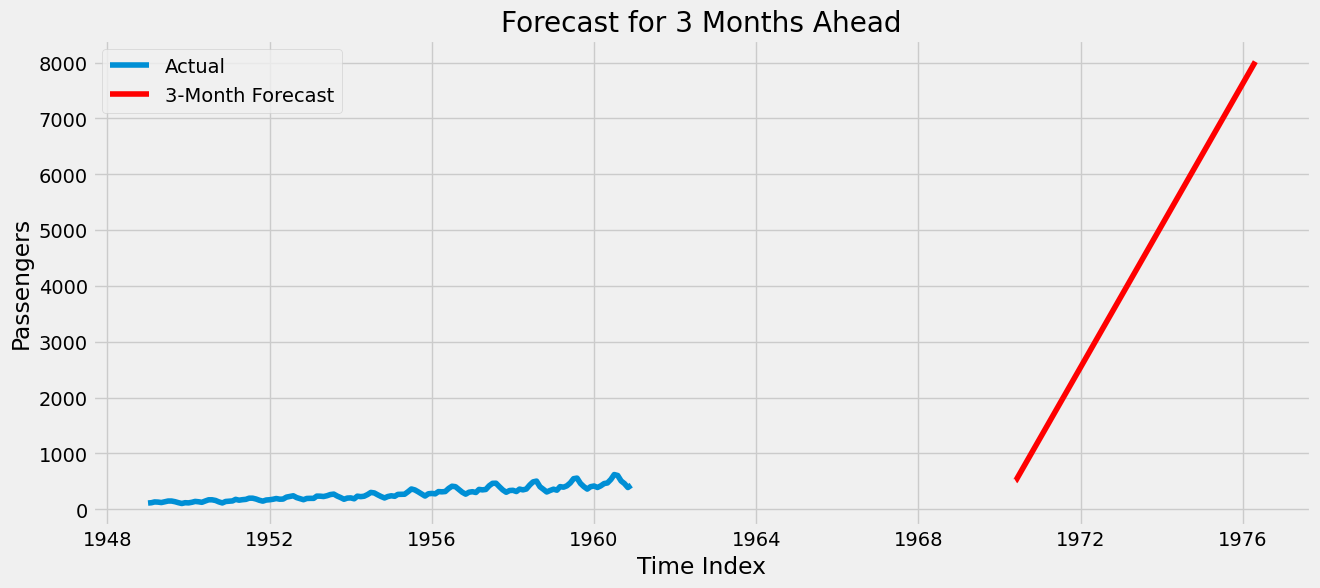

In [54]:
plt.figure(figsize=(14,6))
plt.plot(df.index, df['Passengers'], label='Actual')
plt.plot(range(len(df), len(df)+forecast_steps), forecast_3months, label='3-Month Forecast', color='red')
plt.xlabel('Time Index')
plt.ylabel('Passengers')
plt.legend()
plt.title('Forecast for 3 Months Ahead')
plt.show()

# ================================
# SARIMA

# ================================

m = seasonal period (24 for daily pattern in hourly data, 168 for weekly).

Grid search optimizes (p,d,q) × (P,D,Q,m) based on AIC.

Evaluation metrics: MSE, RMSE, MAPE.

Works for hourly, daily, or weekly seasonal data.\

In [55]:
def evaluate_series(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    return {'MSE': mse, 'RMSE': rmse, 'MAPE': mape}

In [57]:
# ------------------------
# 7) SARIMAX (for seasonal data) -- example with weekly seasonality (m=168)
# ------------------------
# اگر داده دارای فصل روزانه یا هفتگی باشه، seasonal_order=(P,D,Q,m)
m = 24   # daily seasonality for hourly data; or 168 for weekly
# برای انتخاب بهترین seasonal order می‌تونی grid search ساده انجام بدی؛ در اینجا یک نمونه SARIMAX اجرا می‌کنیم:
# Manually chosen parameters
order = (1, 1, 1)                # p,d,q
seasonal_order = (1, 0, 1, 12)   # P,D,Q,m; m=12 برای داده ماهانه

sarimax_model = SARIMAX(train['Passengers'],  # فقط سری عددی
                        order=order,
                        seasonal_order=seasonal_order,
                        enforce_stationarity=False,
                        enforce_invertibility=False)

sarimax_res = sarimax_model.fit(disp=False)
print(sarimax_res.summary())



                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  115
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 12)   Log Likelihood                -355.842
Date:                            Thu, 04 Dec 2025   AIC                            721.684
Time:                                    23:35:01   BIC                            734.710
Sample:                                         0   HQIC                           726.956
                                            - 115                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4683      0.347     -1.348      0.178      -1.149       0.213
ma.L1          0.1983      0.384   

In [59]:
pred = sarimax_res.predict(start=len(train), end=len(train)+len(test)-1)
pred = pd.Series(pred, index=test.index)
pred

115    485.731829
116    418.415039
117    355.023982
118    306.312031
119    348.555082
120    356.495841
121    335.547621
122    394.669375
123    382.071352
124    394.934614
125    478.013304
126    540.976292
127    535.368714
128    457.774335
129    385.001160
130    328.958029
131    377.540315
132    386.658556
133    362.582150
134    430.543656
135    416.062570
136    430.849114
137    526.352884
138    598.732208
139    592.286038
140    503.086990
141    419.430219
142    355.005539
143    410.853562
Name: predicted_mean, dtype: float64

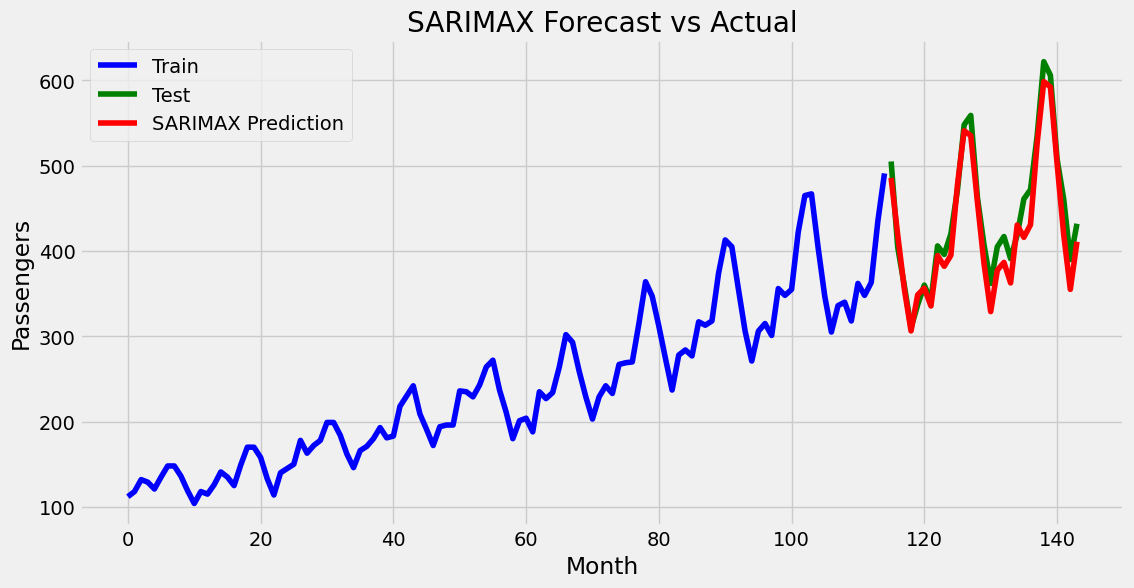

In [61]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train['Passengers'], label='Train', color='blue')
plt.plot(test.index, test['Passengers'], label='Test', color='green')
plt.plot(test.index, pred, label='SARIMAX Prediction', color='red')
plt.title("SARIMAX Forecast vs Actual")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.legend()
plt.show()

# ================================
# Prophet 
# ================================

Notes

-Prophet automatically detects trend, seasonality, and holidays (you can supply a holiday DataFrame if needed).

-Handles missing values and irregular timestamps.

-You can enable multiplicative seasonality via seasonality_mode='multiplicative' if your seasonal effects grow with the level.

-Works well for daily, weekly, and hourly data.

23:43:00 - cmdstanpy - INFO - Chain [1] start processing
23:43:01 - cmdstanpy - INFO - Chain [1] done processing


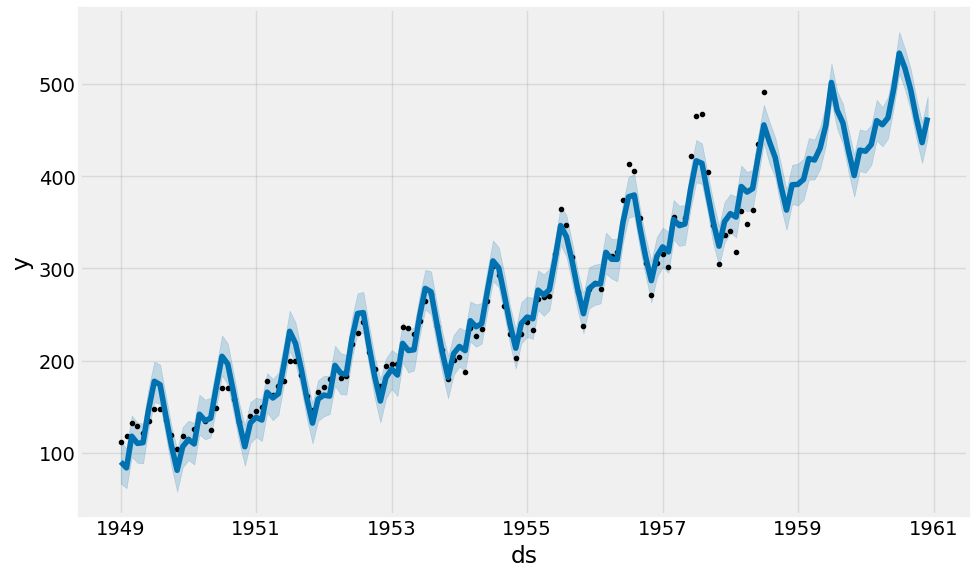

In [66]:
train_df = train.reset_index()[['Month', 'Passengers']]  # اگر Month ایندکس است
train_df.rename(columns={'Month':'ds', 'Passengers':'y'}, inplace=True)
train_df['ds'] = pd.to_datetime(train_df['ds'])  # اطمینان از نوع datetime

model = Prophet(daily_seasonality=False, weekly_seasonality=False, yearly_seasonality=True)

model.fit(train_df)

future = model.make_future_dataframe(periods=len(test), freq='M')

forecast = model.predict(future)

model.plot(forecast)
plt.show()
